# ARTI 403 – Image Processing — **Lab 2**
### Digital Image Fundamentals — Sampling, Quantization & Image Operations

**Imam Abdulrahman Bin Faisal University** · College of Computer Science and Information Technology · Department of Computer Engineering

**Outcome #1:** Explain how digital images are represented and manipulated in a computer.

**Tools / Libraries used (only these):** OpenCV · NumPy · Matplotlib · Pillow (PIL).

**Images** are expected in `images/` next to this notebook: `lena_gray_256.tif`, `cameraman.tif`. `A.png` and `B.png` are created automatically (as binary images) if they are missing.

## Step #1 — Import the libraries

In [16]:
%matplotlib inline
import os
import cv2                        # OpenCV
import numpy as np               # NumPy
import matplotlib.pyplot as plt  # Matplotlib
from PIL import Image            # Pillow (PIL)

print("OpenCV:", cv2.__version__, "| NumPy:", np.__version__, "| Pillow:", Image.__version__)

OpenCV: 5.0.0 | NumPy: 2.1.3 | Pillow: 11.1.0


### Prepare `A.png` and `B.png`
If `images/A.png` and `images/B.png` do not exist, we create two **simple, clear binary images** with OpenCV (a filled circle and a filled square that overlap) so the set/logical operations are visually meaningful. Foreground = 255 (white), background = 0 (black).

In [17]:
os.makedirs('images', exist_ok=True)

if not (os.path.exists('images/A.png') and os.path.exists('images/B.png')):
    size = 300
    # A: filled circle on the left
    A = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(A, (120, 150), 95, 255, -1)
    # B: filled square on the right (overlaps A in the middle)
    B = np.zeros((size, size), dtype=np.uint8)
    cv2.rectangle(B, (150, 60), (260, 240), 255, -1)
    cv2.imwrite('images/A.png', A)
    cv2.imwrite('images/B.png', B)
    print("Created images/A.png and images/B.png (binary).")
else:
    print("A.png and B.png already present.")

print("images/ contents:", sorted(os.listdir('images')))

A.png and B.png already present.
images/ contents: ['A.png', 'B.png', 'cameraman.tif', 'lena_gray_256.tif']


---
# Part 1 — Image Sampling and Quantization

**Sampling** reduces the number of pixels (spatial resolution). **Quantization** reduces the number of gray levels (intensity resolution).

## Step #2 — Define functions
- `sample_image` downsamples using nearest-neighbour interpolation (as in the manual).
- `quantize_image` uses a **corrected** formula that yields *exactly* `levels` distinct gray values (the manual's `256 // levels` formula fails for values like 9). We map each pixel to one of `levels` bins, then spread the bins evenly across 0–255.

In [18]:
def sample_image(image, factor):
    """Downsample the image by the given integer factor (nearest-neighbour)."""
    height, width = image.shape[:2]
    sampled_image = cv2.resize(
        image, (width // factor, height // factor),
        interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """Reduce the image to EXACTLY `levels` distinct gray levels."""
    # bin index in 0 .. levels-1
    idx = np.floor(image.astype(np.float64) / 256.0 * levels)
    idx = np.clip(idx, 0, levels - 1)
    if levels == 1:
        q = np.zeros_like(idx)
    else:
        # spread the `levels` bins evenly across the 0..255 range
        q = np.round(idx * (255.0 / (levels - 1)))
    return q.astype(np.uint8)


def plot_images(original, sampled, quantized):
    """Plot original, sampled and quantized images side by side."""
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(original,  cmap='gray'); plt.title('Original Image');  plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(sampled,   cmap='gray'); plt.title('Sampled Image');   plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(quantized, cmap='gray'); plt.title('Quantized Image'); plt.axis('off')
    plt.show()

## Step #3 — Load the image and set parameters
We load `lena_gray_256.tif` in grayscale. Following the manual we first show one example (sampling factor = 14, quantization levels = 9), then explore several values in **Task #1**.

Loaded: images/lena_gray_256.tif
shape: (256, 256) | dtype: uint8 | min: 0 | max: 254
sampled  shape: (18, 18)
quantized levels produced: 9


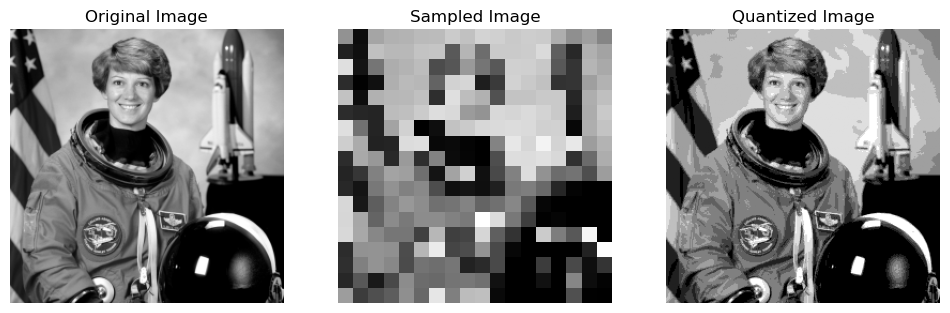

In [19]:
image_path = 'images/lena_gray_256.tif'
sampling_factor = 14
quantization_levels = 9

original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")
else:
    print("Loaded:", image_path)
    print("shape:", original_image.shape, "| dtype:", original_image.dtype,
          "| min:", original_image.min(), "| max:", original_image.max())

sampled_image   = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

print("sampled  shape:", sampled_image.shape)
print("quantized levels produced:", len(np.unique(quantized_image)))
plot_images(original_image, sampled_image, quantized_image)

## Task #1 — Change sampling & quantization parameters and observe the effects

### (a) Sampling with factors 2, 4, 8, 14
Each result is progressively smaller and blockier. Images are shown at the same display size so the loss of spatial detail is visible; the printed shapes show the real pixel dimensions.

factor  2 -> shape (128, 128), dtype uint8
factor  4 -> shape (64, 64), dtype uint8
factor  8 -> shape (32, 32), dtype uint8
factor 14 -> shape (18, 18), dtype uint8


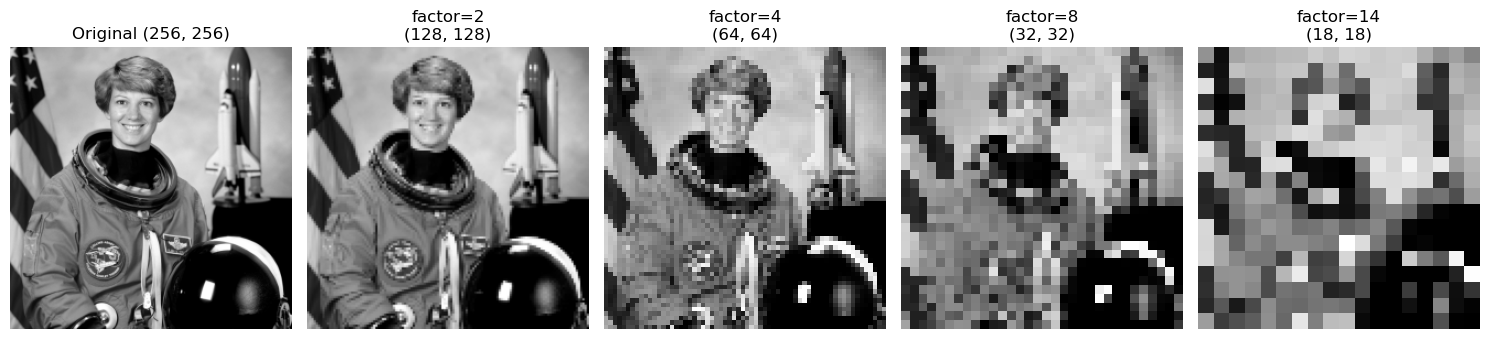

In [20]:
sampling_factors = [2, 4, 8, 14]

plt.figure(figsize=(15, 4))
plt.subplot(1, len(sampling_factors) + 1, 1)
plt.imshow(original_image, cmap='gray'); plt.title(f'Original {original_image.shape}'); plt.axis('off')

for i, f in enumerate(sampling_factors, start=2):
    s = sample_image(original_image, f)
    print(f"factor {f:2d} -> shape {s.shape}, dtype {s.dtype}")
    plt.subplot(1, len(sampling_factors) + 1, i)
    plt.imshow(s, cmap='gray'); plt.title(f'factor={f}\n{s.shape}'); plt.axis('off')
plt.tight_layout(); plt.show()

### (b) Quantization with levels 2, 4, 8, 9, 16
The printed **#unique levels** confirms the corrected formula produces exactly the requested number of gray levels. Fewer levels create visible *false contours* (banding).

levels requested  2 -> #unique levels produced: 2, values sample: [  0 255] ...
levels requested  4 -> #unique levels produced: 4, values sample: [  0  85 170 255] ...
levels requested  8 -> #unique levels produced: 8, values sample: [  0  36  73 109 146] ...
levels requested  9 -> #unique levels produced: 9, values sample: [  0  32  64  96 128] ...
levels requested 16 -> #unique levels produced: 16, values sample: [ 0 17 34 51 68] ...


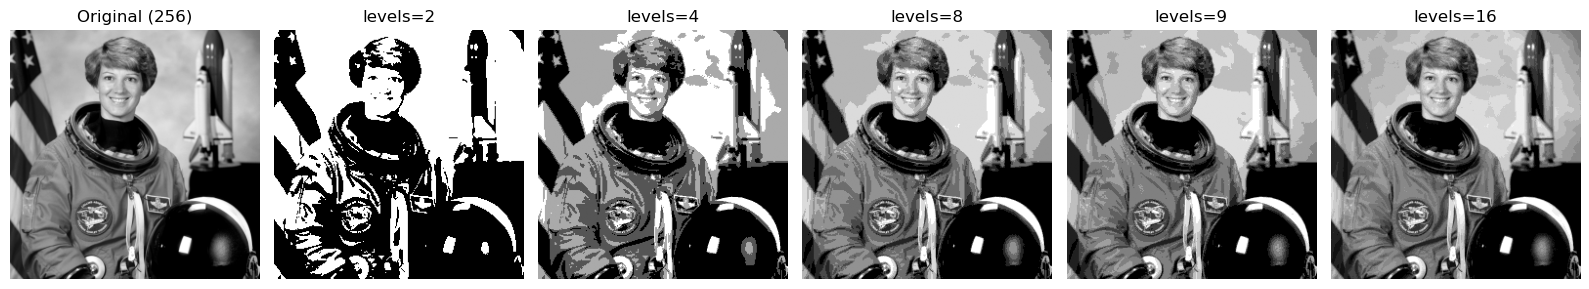

In [21]:
quant_levels = [2, 4, 8, 9, 16]

plt.figure(figsize=(16, 4))
plt.subplot(1, len(quant_levels) + 1, 1)
plt.imshow(original_image, cmap='gray'); plt.title('Original (256)'); plt.axis('off')

for i, L in enumerate(quant_levels, start=2):
    q = quantize_image(original_image, L)
    print(f"levels requested {L:2d} -> #unique levels produced: {len(np.unique(q))}, "
          f"values sample: {np.unique(q)[:5]} ...")
    plt.subplot(1, len(quant_levels) + 1, i)
    plt.imshow(q, cmap='gray', vmin=0, vmax=255); plt.title(f'levels={L}'); plt.axis('off')
plt.tight_layout(); plt.show()

## Notes — effect of changing Sampling and Quantization

**Sampling (spatial resolution).** Increasing the sampling factor keeps fewer pixels, so the image becomes smaller and blockier. Fine details (edges, textures) are lost and, when the image is viewed at its original size, it looks pixelated/staircased. The storage size drops roughly with the square of the factor. Lower factor → more pixels → sharper; higher factor → fewer pixels → coarser.

**Quantization (intensity resolution).** Reducing the number of gray levels forces many nearby intensities to collapse onto a few values. With very few levels (e.g. 2 or 4) smooth gradients turn into flat bands separated by sharp jumps — *false contouring* — and subtle shading disappears. As the number of levels grows (16 and up) the image looks closer to the original. Sampling changes *how many pixels* there are; quantization changes *how many shades* each pixel can take.

---
# Part 2 — Arithmetic Operations (Task #2)

We read two images, convert them to **grayscale**, and **unify their dimensions** before any operation.

Image 1 (lena)      -> shape: (256, 256) dtype: uint8 min/max: 0 254
Image 2 (cameraman) -> shape: (256, 256) dtype: uint8 min/max: 2 255


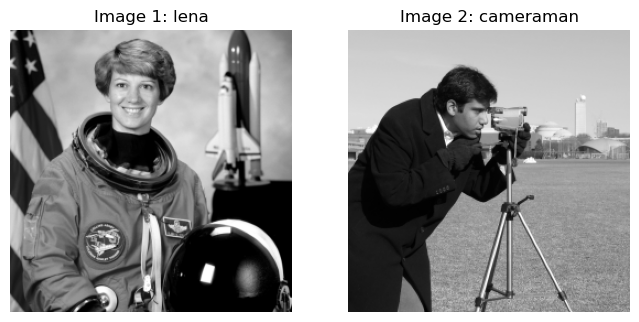

In [22]:
# Load lena and cameraman, force grayscale, unify size to 256x256
SIZE = (256, 256)  # (width, height)

g1 = cv2.imread('images/lena_gray_256.tif', cv2.IMREAD_GRAYSCALE)
g2 = cv2.imread('images/cameraman.tif',     cv2.IMREAD_GRAYSCALE)

im1 = cv2.resize(g1, SIZE, interpolation=cv2.INTER_AREA)
im2 = cv2.resize(g2, SIZE, interpolation=cv2.INTER_AREA)

print("Image 1 (lena)      -> shape:", im1.shape, "dtype:", im1.dtype, "min/max:", im1.min(), im1.max())
print("Image 2 (cameraman) -> shape:", im2.shape, "dtype:", im2.dtype, "min/max:", im2.min(), im2.max())

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(im1, cmap='gray'); plt.title('Image 1: lena');      plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(im2, cmap='gray'); plt.title('Image 2: cameraman'); plt.axis('off')
plt.show()

### (a) Subtract two images
`cv2.subtract` performs **saturating** subtraction, so results below 0 are clamped to 0 (no underflow wrap-around).

subtracted -> shape: (256, 256) dtype: uint8 min: 0 max: 230


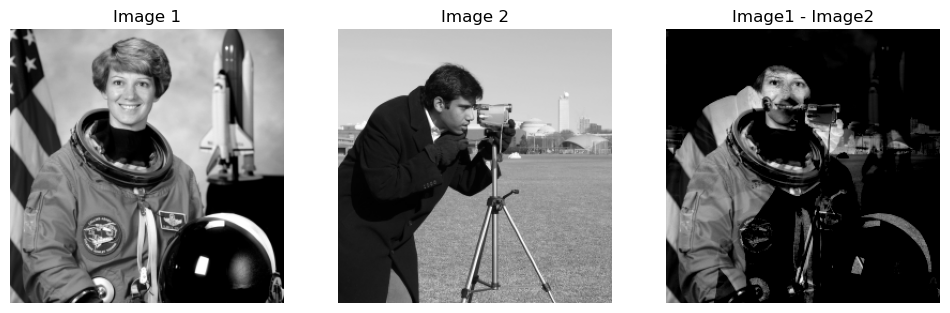

In [23]:
subtracted = cv2.subtract(im1, im2)   # saturating: values < 0 become 0

print("subtracted -> shape:", subtracted.shape, "dtype:", subtracted.dtype,
      "min:", subtracted.min(), "max:", subtracted.max())

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(im1, cmap='gray');        plt.title('Image 1');           plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(im2, cmap='gray');        plt.title('Image 2');           plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(subtracted, cmap='gray'); plt.title('Image1 - Image2');   plt.axis('off')
plt.show()

### (b) Add a constant value of 175 (with overflow prevention)
Adding 175 to 8-bit pixels would exceed 255 and wrap around. We prevent this two equivalent ways:
- **OpenCV:** `cv2.add(img, 175)` saturates automatically at 255.
- **NumPy clipping:** compute in a larger type then `np.clip(..., 0, 255)`.
The printed max confirms no value exceeds 255.

added (OpenCV) -> min: 175 max: 255 dtype: uint8
added (NumPy)  -> min: 175 max: 255 dtype: uint8
both methods identical: True


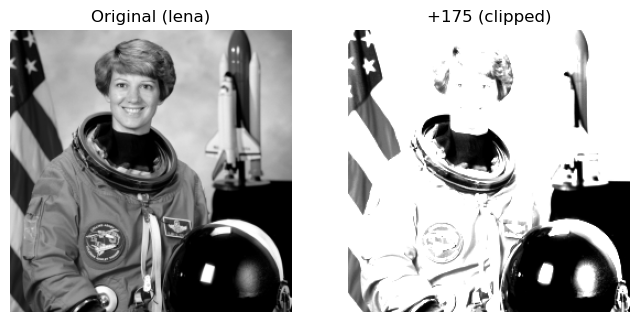

In [24]:
# Method 1 — OpenCV saturating add
added_cv = cv2.add(im1, np.full_like(im1, 175))

# Method 2 — NumPy with clipping (same result)
added_np = np.clip(im1.astype(np.int16) + 175, 0, 255).astype(np.uint8)

print("added (OpenCV) -> min:", added_cv.min(), "max:", added_cv.max(), "dtype:", added_cv.dtype)
print("added (NumPy)  -> min:", added_np.min(), "max:", added_np.max(), "dtype:", added_np.dtype)
print("both methods identical:", np.array_equal(added_cv, added_np))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(im1, cmap='gray');      plt.title('Original (lena)'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(added_cv, cmap='gray'); plt.title('+175 (clipped)');  plt.axis('off')
plt.show()

---
# Part 3 — Sets & Logical Operations (Task #2)

Operations on `A.png` and `B.png`. Both are converted to **grayscale** and resized to the **same dimensions**, then made strictly binary (0 / 255). For binary images the set operations are:

| Set operation | Meaning | Implementation |
|---|---|---|
| Union $A \cup B$ | in A **or** B | `cv2.bitwise_or(A, B)` |
| Intersection $A \cap B$ | in A **and** B | `cv2.bitwise_and(A, B)` |
| Set difference $A \setminus B$ | in A but **not** B | `cv2.bitwise_and(A, cv2.bitwise_not(B))` |
| Symmetric difference $A \triangle B$ | in exactly one | `cv2.bitwise_xor(A, B)` |

A -> shape: (300, 300) dtype: uint8 unique: [  0 255]
B -> shape: (300, 300) dtype: uint8 unique: [  0 255]
white pixels  A: 28345 | B: 20091


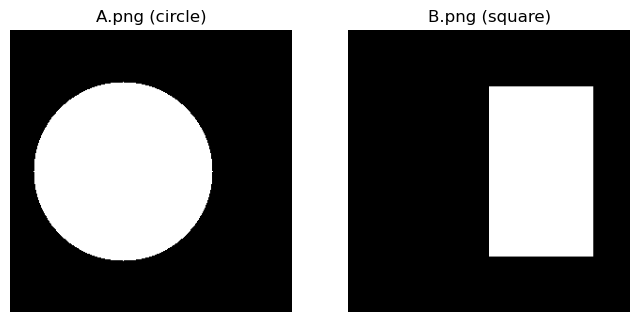

In [25]:
# Load A and B as grayscale and unify dimensions
SET_SIZE = (300, 300)
a = cv2.imread('images/A.png', cv2.IMREAD_GRAYSCALE)
b = cv2.imread('images/B.png', cv2.IMREAD_GRAYSCALE)
a = cv2.resize(a, SET_SIZE, interpolation=cv2.INTER_NEAREST)
b = cv2.resize(b, SET_SIZE, interpolation=cv2.INTER_NEAREST)

# make strictly binary (0 / 255)
_, A = cv2.threshold(a, 127, 255, cv2.THRESH_BINARY)
_, B = cv2.threshold(b, 127, 255, cv2.THRESH_BINARY)

print("A -> shape:", A.shape, "dtype:", A.dtype, "unique:", np.unique(A))
print("B -> shape:", B.shape, "dtype:", B.dtype, "unique:", np.unique(B))
print("white pixels  A:", int((A == 255).sum()), "| B:", int((B == 255).sum()))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(A, cmap='gray'); plt.title('A.png (circle)'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(B, cmap='gray'); plt.title('B.png (square)'); plt.axis('off')
plt.show()

Union                    -> white pixels:  39772 | unique: [  0 255]
Intersection             -> white pixels:   8664 | unique: [  0 255]
Set difference (A\B)     -> white pixels:  19681 | unique: [  0 255]
Symmetric difference     -> white pixels:  31108 | unique: [  0 255]
check |A∪B| == |A∩B| + |A△B| : True


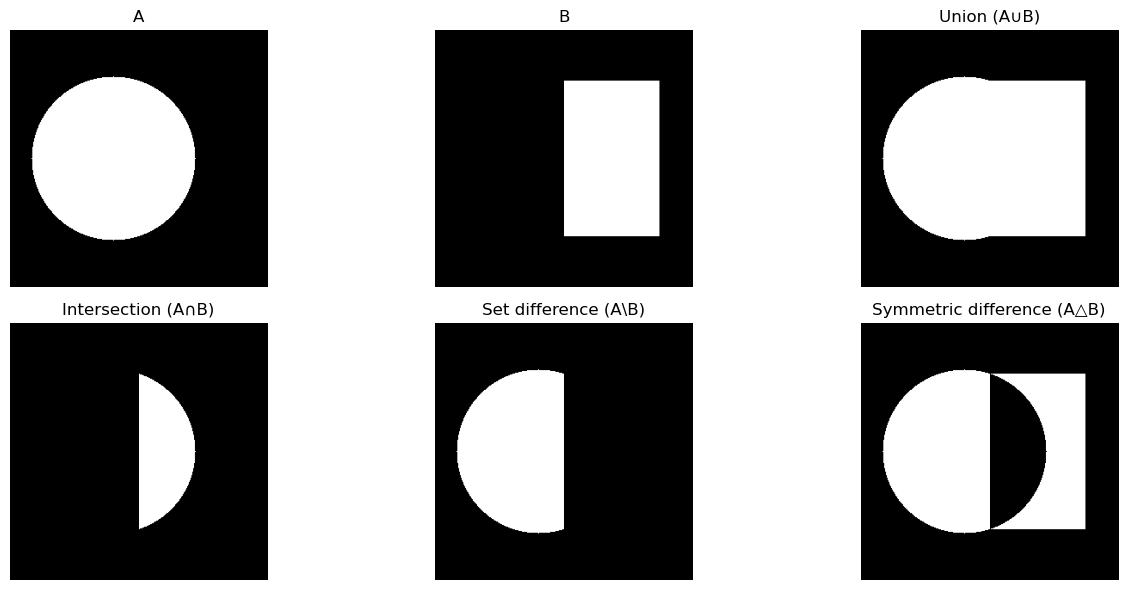

In [26]:
union      = cv2.bitwise_or(A, B)                      # A ∪ B
intersect  = cv2.bitwise_and(A, B)                     # A ∩ B
set_diff   = cv2.bitwise_and(A, cv2.bitwise_not(B))    # A \ B
sym_diff   = cv2.bitwise_xor(A, B)                     # A △ B

for name, r in [("Union", union), ("Intersection", intersect),
                ("Set difference (A\\B)", set_diff), ("Symmetric difference", sym_diff)]:
    print(f"{name:24s} -> white pixels: {int((r==255).sum()):6d} | unique: {np.unique(r)}")

# sanity check: union pixels == intersection + symmetric-difference pixels
print("check |A∪B| == |A∩B| + |A△B| :",
      int((union==255).sum()) == int((intersect==255).sum()) + int((sym_diff==255).sum()))

plt.figure(figsize=(14, 6))
imgs = [("A", A), ("B", B), ("Union (A∪B)", union),
        ("Intersection (A∩B)", intersect),
        ("Set difference (A\\B)", set_diff),
        ("Symmetric difference (A△B)", sym_diff)]
for i, (t, im) in enumerate(imgs, start=1):
    plt.subplot(2, 3, i); plt.imshow(im, cmap='gray'); plt.title(t); plt.axis('off')
plt.tight_layout(); plt.show()

### Summary
- **Part 1 — Sampling & Quantization:** downsampled Lena at factors 2, 4, 8, 14 and quantized to 2, 4, 8, 9, 16 levels using a corrected formula that yields exactly the requested number of levels; notes explain the visual effects.
- **Part 2 — Arithmetic:** subtracted two grayscale images (saturating) and added a constant 175 with overflow prevented via `cv2.add` / `np.clip`.
- **Part 3 — Sets & Logic:** computed Union, Intersection, Set difference and Symmetric difference on binary `A.png` / `B.png`, after grayscale conversion and dimension unification.

All images and results are displayed with Matplotlib, and shapes / dtypes / key values are printed throughout for verification — demonstrating how digital images are represented and manipulated (**Outcome #1**).